In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
import threading
import sys
import scipy.stats as sts

"Ok"

'Ok'

In [4]:
SEED = 42  # Случайное начальное число
PROBABILITY = 0.09  # Вероятность появления ребра
N_RANGE = range(5, 1001, 3)  # Количество вершин
DRAW_AND_QUIT = -1  # Преждевременная остановка с визуализацией графа (-1 - откл.)
RETESTS = 30  # Количество испытаний для каждого числа вершин
MAX_RUNTIME = 120
STOP_NOW = False

times_mean = []  # среднее время выполнения
times_std = []  # среднее квадратичное отклонение по времени выполнения
selected_times, selected_i = None, None

times = np.array([None] * RETESTS)  # Массив фактического времени выполнения длины RETESTS
pointer = 0  # Указатель на индекс массива times

In [14]:
# Декоратор, измеряющий время исполнения алгоритма
def measure_execution_time(func):
    def wrapper(*args, **kwargs):
        global times, pointer

        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        times[pointer] = execution_time
        pointer = (pointer + 1) % RETESTS

        return result

    return wrapper

In [15]:
class ConnectivityList:
    def __init__(self, graph: nx.Graph):
        """Объект хранит список связности и количество вершин графа (см. Идея 2 Список связности)"""
        self.conlist = []
        self.length = graph.number_of_nodes()
        # Для каждой вершины будем хранить маску связности в списке связности по индексу с номером этой вершины
        for node in range(self.length):
            self.conlist.append(self.to_binary(graph.neighbors(node)))

    @staticmethod
    def to_binary(neighbors) -> int:
        """Метод создает на основе итератора битовую маску, где каждый бит хранит связь текущей вершины с i-м соседом"""
        binary = 0

        # Создаем маску связности
        for i in neighbors:
            binary |= 1 << i
        return binary

    def __str__(self) -> str:
        """Метод создает текстовое представление списка связности"""
        res_str = ""
        for node, mask in enumerate(self.conlist):
            res_str += f"{node}: {bin(mask)}\n"

        return res_str

    def check_independence(self, subset: int) -> bool:
        """Метод проверяет независимость элементов подмножества с помощью маски соседей (см. Идея 1 Битовая маска)"""
        neighbors_mask = 0
        temp = subset
        index = 0
        while temp:
            if temp & 1:
                neighbors_mask |= self.conlist[index]
            temp >>= 1
            index += 1

        if not neighbors_mask & subset:
            return True

        return False

In [16]:
@measure_execution_time
def algorithm(graph: nx.Graph) -> int:
    global STOP_NOW

    cl = ConnectivityList(graph)
    misl = 1  # max independent set length (искомое значение)

    independent_subsets = [0, 1]
    step = 1
    while step < cl.length:
        l = len(independent_subsets)
        for i in range(l):
            if STOP_NOW:
                output()
            # Добавляем к подмножеству новую вершину
            new_subset = independent_subsets[i] | (1 << step)

            # Проверка на независимость
            if cl.check_independence(new_subset):
                nodes_count = new_subset.bit_count()
                if nodes_count > misl:
                    misl = nodes_count

                # Добавляем только "перспективные" подмножества
                if nodes_count + cl.length - step - 1 > misl:
                    independent_subsets.append(new_subset)
        step += 1

    return misl

In [17]:
def stop():
    global STOP_NOW
    STOP_NOW = True


def sort_graph(graph: nx.Graph):
    # Объявляем новый порядок вершин по возрастанию степеней
    node_order = [node for node, _ in sorted(dict(graph.degree()).items(), key=lambda x: x[1])]
    # Сопоставляем каждой вершине её новое название
    mapping = {old: new for new, old in enumerate(node_order)}
    # переименовываем вершены, сохраняем полученную копию в новую переменную
    return nx.relabel_nodes(graph, mapping)


def main():
    global times_mean, times_std, times, selected_times, selected_i

    timer = threading.Timer(MAX_RUNTIME * 60, stop)
    timer.start()

    i = 0

    for n in N_RANGE:

        offset = 0
        for _ in range(RETESTS):
            sorted_graph = sort_graph(
                nx.erdos_renyi_graph(n, p=min(PROBABILITY + (PROBABILITY / 16) * offset, 0.3), seed=SEED + offset))

            result = algorithm(sorted_graph)

            if DRAW_AND_QUIT != -1 and n >= DRAW_AND_QUIT:
                print(result)
                pos = nx.spring_layout(sorted_graph)
                nx.draw(sorted_graph, pos, with_labels=True, node_color='lightblue', node_size=500)
                plt.show()
                timer.cancel()
                sys.exit(0)

            offset += 1

        selected_times, selected_i = times, i
        times_mean.append(times.mean())
        times_std.append(times.std())

        i += 1

    timer.cancel()
    output()


def output():
    global times_mean, times_std, N_RANGE

    print(times_mean)
    print(times_std)

    plt.plot(list(N_RANGE[:len(times_mean)]), times_mean)
    plt.show()

    sys.exit(0)

[np.float64(1.7080000179703348e-05), np.float64(7.957333339921509e-05), np.float64(0.00045776333330043903), np.float64(0.0022563633331931974), np.float64(0.00903334666666827), np.float64(0.03452233000025444), np.float64(0.12288776333346808), np.float64(0.3780494266663785), np.float64(1.4102835200001815), np.float64(4.265661646667043), np.float64(15.827680806667074), np.float64(48.4289047066668), np.float64(82.60926599000037)]
[np.float64(1.1502098465878727e-05), np.float64(9.899223423364067e-06), np.float64(9.18168230033739e-05), np.float64(0.0007434582946350675), np.float64(0.0035336643411339316), np.float64(0.019688591665010375), np.float64(0.11507340619972108), np.float64(0.3716050054421282), np.float64(1.4700437098431194), np.float64(4.930195397901059), np.float64(14.33835871398396), np.float64(86.50081187673929), np.float64(136.83748172801938)]


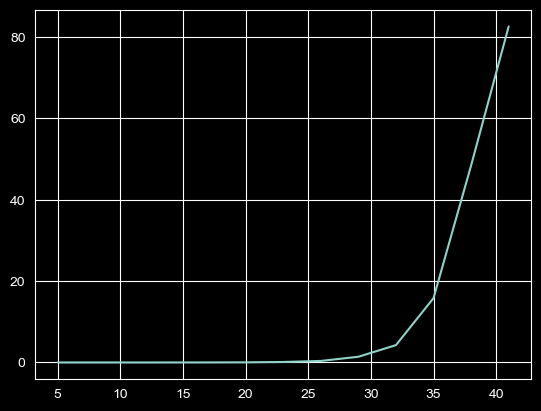

SystemExit: 0

In [18]:
main()

In [5]:
# # Вход:
# SEED = 42
# PROBABILITY = 0.09
# N_RANGE = range(5, 1001, 3)
# DRAW_AND_QUIT = -1
# RETESTS = 30
# MAX_RUNTIME = 120
#
# # Полученные данные:
# times_mean = [np.float64(1.7080000179703348e-05), np.float64(7.957333339921509e-05), np.float64(0.00045776333330043903), np.float64(0.0022563633331931974), np.float64(0.00903334666666827), np.float64(0.03452233000025444), np.float64(0.12288776333346808), np.float64(0.3780494266663785), np.float64(1.4102835200001815), np.float64(4.265661646667043), np.float64(15.827680806667074), np.float64(48.4289047066668), np.float64(82.60926599000037)]
# times_std = [np.float64(1.1502098465878727e-05), np.float64(9.899223423364067e-06), np.float64(9.18168230033739e-05), np.float64(0.0007434582946350675), np.float64(0.0035336643411339316), np.float64(0.019688591665010375), np.float64(0.11507340619972108), np.float64(0.3716050054421282), np.float64(1.4700437098431194), np.float64(4.930195397901059), np.float64(14.33835871398396), np.float64(86.50081187673929), np.float64(136.83748172801938)]
#
# selected_times = np.array([654.1791195000005, 243.29110030000083, 89.6091155000031,
#        414.6372718999992, 154.58440060000066, 145.32429639999827,
#        147.5553961000005, 63.849035499999445, 94.90461960000175,
#        34.41067610000027, 44.79552650000187, 54.63929149999967,
#        51.15745340000285, 79.25785330000144, 25.710082599998714,
#        16.75478729999668, 38.39506900000197, 22.25434270000187,
#        29.62300299999697, 9.704007699998328, 11.014697499998874,
#        8.181831500001863, 4.421922400000767, 4.4991571999999,
#        14.84373240000059, 5.001874699999462, 4.301737400001002,
#        5.453749899999821, 3.1420533000018622, 2.780774900002143],
#       dtype=object)
#
# selected_i = 12

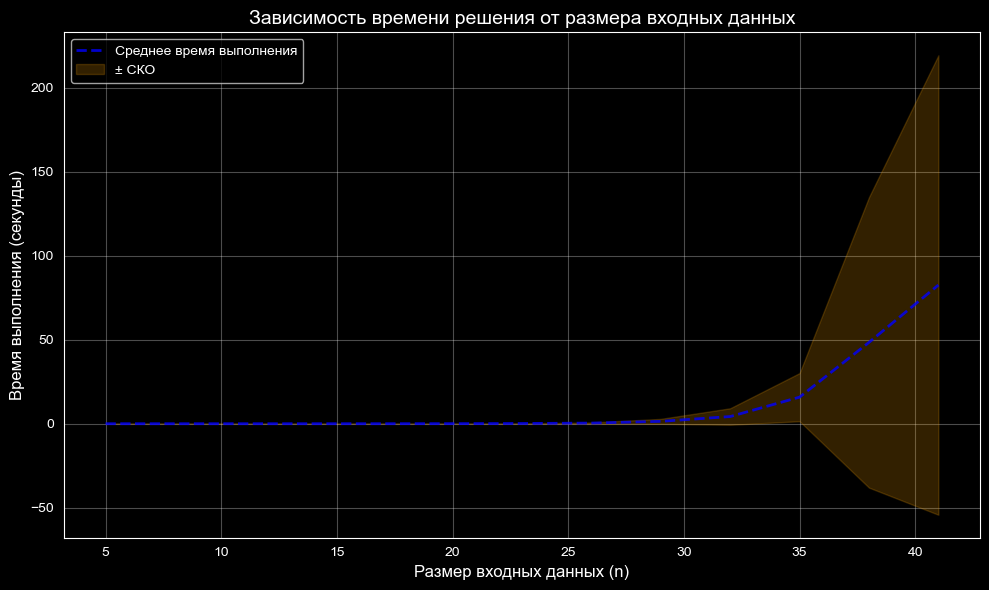

In [8]:
plt.figure(figsize=(10, 6))

n_np = np.array(list(N_RANGE[:len(times_mean)]))
times_mean_np = np.array(times_mean)
times_std_np = np.array(times_std)

plt.plot(n_np, times_mean_np, 'b--', linewidth=2, alpha=0.8, label='Среднее время выполнения')

plt.fill_between(n_np,
                 times_mean_np - times_std_np,
                 times_mean_np + times_std_np,
                 color='orange', alpha=0.2, label='± СКО')

plt.xlabel('Размер входных данных (n)', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Зависимость времени решения от размера входных данных', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
BINS = 30

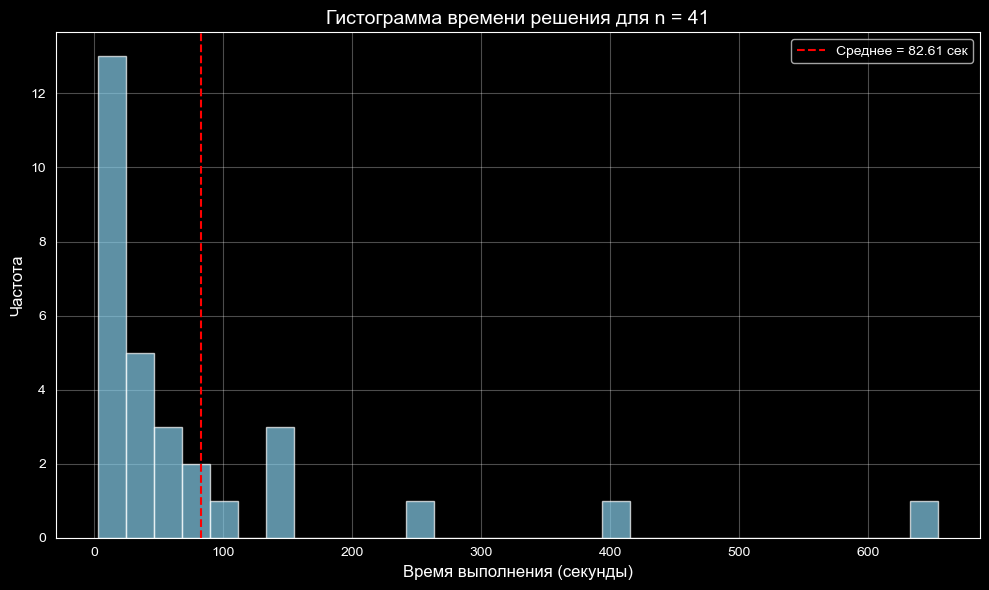

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(selected_times, bins=BINS, color='skyblue', alpha=0.7).
plt.axvline(times_mean_np[selected_i], color='red', linestyle='--', linewidth=1.5,
            label=f'Среднее = {times_mean_np[selected_i]:.2f} сек')
plt.xlabel('Время выполнения (секунды)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма времени решения для n = {n_np[selected_i]}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
selected_times

array([654.1791195000005, 243.29110030000083, 89.6091155000031,
       414.6372718999992, 154.58440060000066, 145.32429639999827,
       147.5553961000005, 63.849035499999445, 94.90461960000175,
       34.41067610000027, 44.79552650000187, 54.63929149999967,
       51.15745340000285, 79.25785330000144, 25.710082599998714,
       16.75478729999668, 38.39506900000197, 22.25434270000187,
       29.62300299999697, 9.704007699998328, 11.014697499998874,
       8.181831500001863, 4.421922400000767, 4.4991571999999,
       14.84373240000059, 5.001874699999462, 4.301737400001002,
       5.453749899999821, 3.1420533000018622, 2.780774900002143],
      dtype=object)

𝐻0: 𝐹1
(𝑥) = 𝐹2
(𝑥), 𝑥 ∈ ℝ,

𝐻1: 𝐹1
(𝑥) ≠ 𝐹2
(𝑥), для некоторых 𝑥 ∈ ℝ.

Где F1 - функция распределения времени выполнения, F2 - функция экспоненциального распределения

Проверим гипотезу H0 по критерию однородности 𝝌^2

In [85]:
l = BINS - 1 # Число интервалов группировки
alpha = 0.05 # Уровень значимости
m = 1 # Число параметров распределения
observed, bins = np.histogram(selected_times, l)
lam = 1 / selected_times.mean()

expected = []
for i in range(l):
    a, b = bins[i], bins[i+1]
    prob = (1 - np.exp(-lam * b)) - (1 - np.exp(-lam * a))
    expected.append(len(selected_times) * prob)

expected = np.array(expected)

chi2_obs = sum((expected - observed) ** 2 / (expected + observed)) # Статистика критерия однородности 𝝌^2
chi2_crit = sts.chi2.ppf(1 - alpha, l - m - 1) # Критическое значение статистики

print("Не отвергаем гипотезу HO") if chi2_obs <= chi2_crit else print("Отвергаем гипотезу HO")

Не отвергаем гипотезу HO


In [86]:
chi2_obs, chi2_crit

(np.float64(11.01668702514191), np.float64(40.113272069413625))

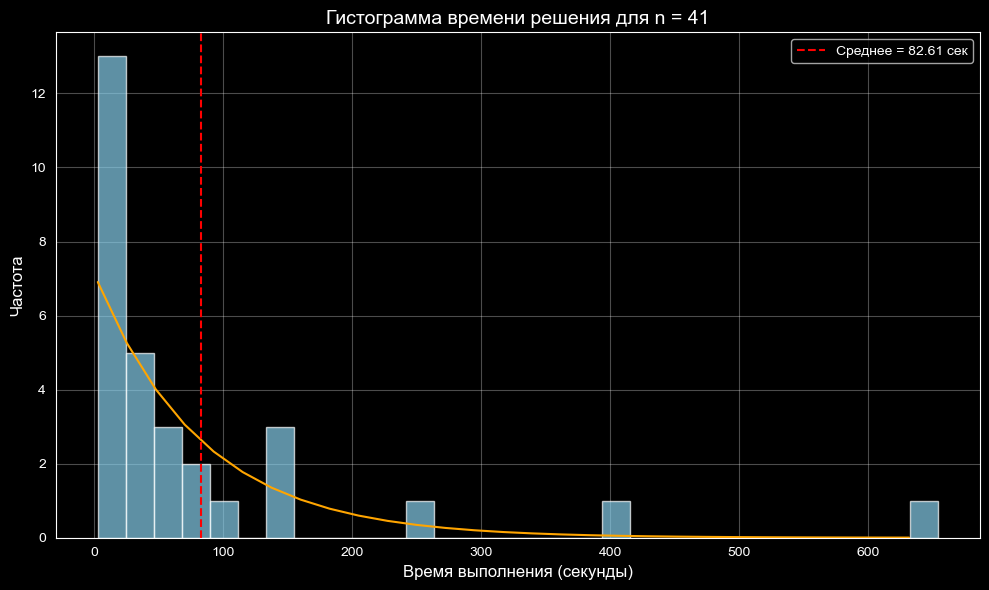

In [90]:
plt.figure(figsize=(10, 6))
plt.hist(selected_times, bins=30, color='skyblue', alpha=0.7)
plt.plot(bins[:-1], expected, c="orange")
plt.axvline(times_mean_np[selected_i], color='red', linestyle='--', linewidth=1.5,
            label=f'Среднее = {times_mean_np[selected_i]:.2f} сек')
plt.xlabel('Время выполнения (секунды)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма времени решения для n = {n_np[selected_i]}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
